
Welcome! Get ready to analyze your portfolio.

╔══════════════════════════════════════════════════╗
║ INTERACTIVE PORTFOLIO ANALYZER                   ║
╠══════════════════════════════════════════════════╣
║ Configuration (User Inputs)                      ║
║ • Portfolio tickers                              ║
║ • Asset weights                                  ║
║ • Risk-free rate / asset                         ║
║ • Market benchmark                               ║
║ • Analysis period                                ║
║ • Trading days per year                          ║
╠══════════════════════════════════════════════════╣
║ Analysis Includes                                ║
║ • Returns (total & annualized)                   ║
║ • Individual & portfolio analysis                ║
║ • Risk-adjusted performance ratios               ║
║ • Beta estimation & CAPM                         ║
║ • Risk analysis (volatility, drawdowns)          ║
║ • Performance vs benchmark                       

Portfolio tickers (comma-separated, e.g., AAPL,MSFT,GOOG):  TSLA, NVDA, AAPL, MSFT, AMZN, COST, JNJ, ABBV, KO, PG, VZ, T, DUK, NEE
Weights for 14 tickers (comma-separated, sum to 1, e.g., 0.4,0.4,0.2):  0.05, 0.05, 0.08, 0.08, 0.07, 0.07, 0.10, 0.10, 0.10, 0.10, 0.05, 0.05, 0.05, 0.05
Risk-free ticker (e.g., ^IRX, ^TNX):  ^IRX
Market benchmark ticker (e.g., ^GSPC, ^DJI):  ^GSPC


✅ All inputs validated and ready for analysis!

╔══════════════════════════════════════════════════╗
║ PORTFOLIO SUMMARY                                ║
╠══════════════════════════════════════════════════╣
║ Tickers & Weights:                               ║
║ TSLA: 0.05                                       ║
║ NVDA: 0.05                                       ║
║ AAPL: 0.08                                       ║
║ MSFT: 0.08                                       ║
║ AMZN: 0.07                                       ║
║ COST: 0.07                                       ║
║ JNJ: 0.10                                        ║
║ ABBV: 0.10                                       ║
║ KO: 0.10                                         ║
║ PG: 0.10                                         ║
║ VZ: 0.05                                         ║
║ T: 0.05                                          ║
║ DUK: 0.05                                        ║
║ NEE: 0.05                                        

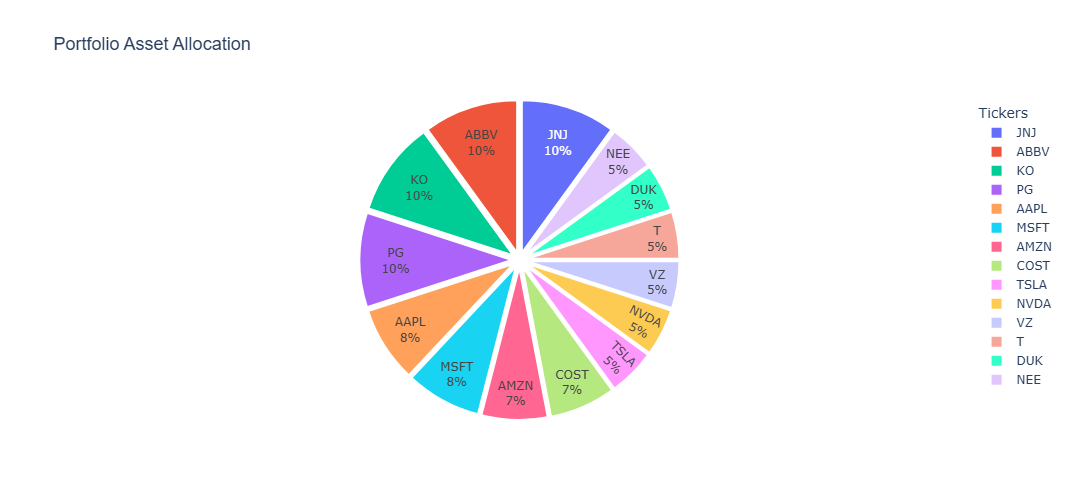

 Please enter your inputs!
✅ All inputs validated and ready for analysis!


Enter the analysis period in whole years (e.g., 1, 2, 5):  5



╔══════════════════════════════════════════════════╗
║ ANALYSIS PERIOD SUMMARY                          ║
╠══════════════════════════════════════════════════╣
║ Start Date : 2021-03-31                          ║
║ End Date   : 2026-03-31                          ║
║ Duration   : 5 year(s) (1826 days)               ║
╚══════════════════════════════════════════════════╝



In [1]:
# --------------------------------------------------------------------------------------------
# Interactive Portfolio Analyzer (Simple & Robust)
# --------------------------------------------------------------------------------------------


import numpy as np
import pandas as pd
import yfinance as yf
from datetime import datetime
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import plotly.express as px
import statsmodels.api as sm
import plotly.graph_objects as go
import seaborn as sns
import scipy.stats as stats
import quantstats as qs
qs.extend_pandas()  
import statsmodels.api as sm
from plotly.subplots import make_subplots
from scipy.stats import gaussian_kde

trading_days = 252

# Print welcome message above the table
print("\nWelcome! Get ready to analyze your portfolio.\n")

def print_header():
    max_width = 50  
    line = "═" * max_width

    def fmt(text):
        # pad text to fit max_width
        padding = max_width - 2 - len(text)  
        return f"║ {text}{' ' * padding} ║"

    print(f"╔{line}╗")
    print(fmt("INTERACTIVE PORTFOLIO ANALYZER"))
    print(f"╠{line}╣")

    print(fmt("Configuration (User Inputs)"))
    print(fmt("• Portfolio tickers"))
    print(fmt("• Asset weights"))
    print(fmt("• Risk-free rate / asset"))
    print(fmt("• Market benchmark"))
    print(fmt("• Analysis period"))
    print(fmt("• Trading days per year"))

    print(f"╠{line}╣")

    print(fmt("Analysis Includes"))
    print(fmt("• Returns (total & annualized)"))
    print(fmt("• Individual & portfolio analysis"))
    print(fmt("• Risk-adjusted performance ratios"))
    print(fmt("• Beta estimation & CAPM"))
    print(fmt("• Risk analysis (volatility, drawdowns)"))
    print(fmt("• Performance vs benchmark"))

    print(f"╠{line}╣")

    print(fmt("Assumptions & Notes"))
    print(fmt("• Weights sum to 1.0"))
    print(fmt("• Data sourced via yfinance"))

    print(f"╚{line}╝\n")

print_header()

def print_portfolio_summary(tickers, weights, rf_ticker, market_ticker):
    max_width = 50
    line = "═" * max_width

    def fmt(text):
        padding = max_width - 2 - len(text)
        return f"║ {text}{' ' * padding} ║"

    print(f"\n╔{line}╗")
    print(fmt("PORTFOLIO SUMMARY"))
    print(f"╠{line}╣")

    print(fmt("Tickers & Weights:"))
    for t, w in zip(tickers, weights):
        print(fmt(f"{t}: {w:.2f}"))

    print(f"╠{line}╣")
    print(fmt(f"Risk-Free Ticker: {rf_ticker}"))
    print(fmt(f"Market Benchmark: {market_ticker}"))
    print(f"╚{line}╝\n")

# --- Step 1: Portfolio Tickers ---
tickers_input = input("Portfolio tickers (comma-separated, e.g., AAPL,MSFT,GOOG): ")
tickers = [t.strip().upper() for t in tickers_input.split(",")]

# --- Validate tickers ---
if len(tickers) < 2:
    raise ValueError("You must enter at least two tickers for the portfolio.")
if len(tickers) != len(set(tickers)):
    raise ValueError("Duplicate tickers found. Each ticker must be unique.")

# --- Step 2: Portfolio Weights ---
weights_input = input(f"Weights for {len(tickers)} tickers (comma-separated, sum to 1, e.g., 0.4,0.4,0.2): ")
try:
    weights = [float(w.strip()) for w in weights_input.split(",")]
except ValueError:
    raise ValueError("Weights must be numeric values.")

# --- Validate weights ---
if len(weights) != len(tickers):
    raise ValueError("Number of weights must match number of tickers.")
if any(w < 0 for w in weights):
    raise ValueError("Weights cannot be negative.")
if sum(weights) == 0:
    raise ValueError("Sum of weights cannot be zero.")

# --- Normalize weights ---
weights = np.array(weights, dtype=float)
weights = weights / weights.sum()  # normalize automatically if not exactly 1

# --- Step 3: Risk-Free Ticker ---
rf_ticker_input = input("Risk-free ticker (e.g., ^IRX, ^TNX): ")
rf_ticker = rf_ticker_input.strip().upper()
if not rf_ticker:
    raise ValueError("You must enter a risk-free ticker.")

# --- Step 4: Market Benchmark Ticker ---
market_ticker_input = input("Market benchmark ticker (e.g., ^GSPC, ^DJI): ")
market_ticker = market_ticker_input.strip().upper()
if not market_ticker:
    raise ValueError("You must enter a market benchmark ticker.")

# --- Step 5: Summary ---
print("✅ All inputs validated and ready for analysis!")


def plot_portfolio_weights(tickers, weights):
    # Convert weights to percentages for display
    weights_percent = [w * 100 for w in weights]
    
    fig = px.pie(
        names=tickers,
        values=weights_percent,
        title="Portfolio Asset Allocation",
        hover_data={'Percentage': weights_percent},
        labels={'values':'% Weight'},
    )
    
    fig.update_traces(
        textinfo='label+percent',
        pull=[0.05]*len(tickers),  # slight pull effect for all slices
        marker=dict(line=dict(color='white', width=2))
    )
    
    fig.update_layout(
        width=600,
        height=500,
        title_font=dict(size=18, family="Arial, bold"),
        legend_title="Tickers",
    )
    
    fig.show()



# --- Add after printing the summary ---
print_portfolio_summary(tickers, weights, rf_ticker, market_ticker)
plot_portfolio_weights(tickers, weights)
print(" Please enter your inputs!")
print("✅ All inputs validated and ready for analysis!")

def print_analysis_period_summary(start_date, end_date, years, duration_days):
    max_width = 50
    line = "═" * max_width

    def fmt(text):
        padding = max_width - 2 - len(text)
        return f"║ {text}{' ' * padding} ║"

    print(f"\n╔{line}╗")
    print(fmt("ANALYSIS PERIOD SUMMARY"))
    print(f"╠{line}╣")
    print(fmt(f"Start Date : {start_date.date()}"))
    print(fmt(f"End Date   : {end_date.date()}"))
    print(fmt(f"Duration   : {years} year(s) ({duration_days} days)"))
    print(f"╚{line}╝\n")


# --- Step 1: User-Defined Analysis Duration ---
while True:
    years_input = input("Enter the analysis period in whole years (e.g., 1, 2, 5): ").strip()
    try:
        years = int(years_input)
        if not (1 <= years <= 100):
            raise ValueError
        break
    except ValueError:
        print("❌ Invalid input. Enter a whole number between 1 and 100.")

# Set dates
end_date = pd.Timestamp.today()
start_date = end_date - pd.DateOffset(years=years)

# Calculate duration in days
duration_days = (end_date - start_date).days

# Summary using formatted table
print_analysis_period_summary(start_date, end_date, years, duration_days)


✅ Download completed. Preview of Close prices:


Ticker,AAPL,ABBV,AMZN,COST,DUK,JNJ,KO,MSFT,NEE,NVDA,PG,T,TSLA,VZ
Date,,,,,,,,,,,,,,
2021-03-31,118.973564,89.374443,154.703995,333.710510,79.499565,142.718674,45.414135,226.235352,66.431107,13.314691,119.377792,16.525742,222.643326,42.814800
2021-04-01,119.801453,89.622223,158.050003,336.039490,79.293655,141.398712,45.241817,232.549271,66.571693,13.777026,118.364113,16.634928,220.583328,42.925240
2021-04-05,122.626045,87.656670,161.336502,341.606384,79.828987,141.919769,45.500290,238.997498,67.459061,13.952333,120.276871,16.765953,230.350006,43.344917
2021-04-06,122.927971,87.029007,161.190994,340.943573,80.356071,141.885025,45.827694,237.836472,68.144371,13.826650,120.320930,16.913357,230.539993,43.521626
2021-04-07,124.574028,86.888634,163.969498,339.703430,80.561966,142.076035,45.905239,239.793930,68.012581,14.107942,120.532539,16.886065,223.656662,43.440643


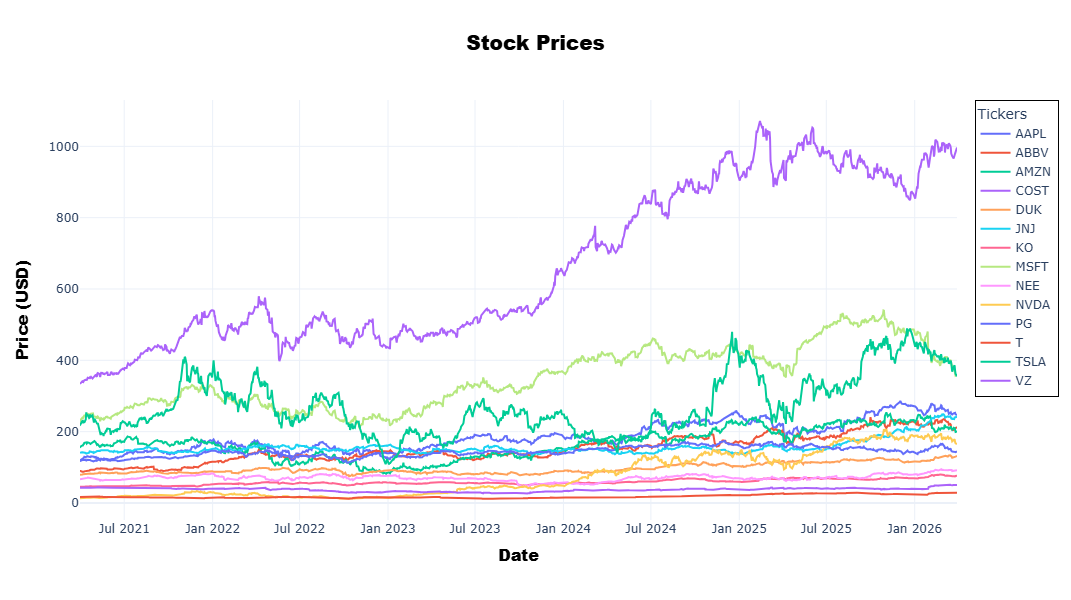

In [2]:
def download_data_close(tickers, start, end):
    try:
        data = yf.download(tickers, start=start, end=end, progress=False)['Close']
    except Exception as e:
        raise RuntimeError(f"Error downloading data: {e}")
    
    if isinstance(data, pd.Series):
        data = data.to_frame()
    
    data = data.ffill().bfill()
    
    downloaded_tickers = data.columns.tolist()
    missing_tickers = [t for t in tickers if t not in downloaded_tickers]
    if missing_tickers:
        print(f"⚠ Warning: Could not download: {missing_tickers}")
    
    return data

# --- Download data ---
data = download_data_close(tickers, start_date, end_date)
print("\n✅ Download completed. Preview of Close prices:")
display(data.head())

# --- Interactive stock prices plot with larger size and legend outside ---
n_tickers = len(data.columns)
fig = go.Figure()

for ticker in data.columns:
    fig.add_trace(
        go.Scatter(
            x=data.index,
            y=data[ticker],
            mode='lines',
            name=ticker
        )
    )

# --- Dynamic size capped to window ---
fig.update_layout(
    width=min(max(400, 100*n_tickers), 1000),  # at least 400, at most 1200
    height=min(600, 700),                      # height 600 but max 700
    title=dict(
        text="Stock Prices",
        font=dict(size=20, family="Arial Black", color="black"),
        x=0.5,
        xanchor='center'
    ),
    xaxis=dict(
        title=dict(text="Date", font=dict(size=16, family="Arial Black", color="black"))
    ),
    yaxis=dict(
        title=dict(text="Price (USD)", font=dict(size=16, family="Arial Black", color="black"))
    ),
    legend=dict(
        title="Tickers",
        orientation="v",
        x=1.02,           # move legend outside the right
        y=1,
        xanchor="left",
        yanchor="top",
        bordercolor="black",
        borderwidth=1,
        font=dict(size=12)
    ),
    template="plotly_white",
    hovermode="x unified"
)

fig.show()

✅ Log returns computed for portfolio tickers.

Portfolio Returns Preview:


Ticker,AAPL,ABBV,AMZN,COST,DUK,JNJ,KO,MSFT,NEE,NVDA,PG,T,TSLA,VZ
Date,,,,,,,,,,,,,,
2021-04-01,0.006934,0.002769,0.021398,0.006955,-0.002593,-0.009292,-0.003802,0.027526,0.002114,0.034134,-0.008528,0.006585,-0.009296,0.002576
2021-04-05,0.023304,-0.022176,0.020581,0.016430,0.006729,0.003678,0.005697,0.027351,0.013241,0.012644,0.016031,0.007846,0.043324,0.009729
2021-04-06,0.002459,-0.007186,-0.000902,-0.001942,0.006581,-0.000245,0.007170,-0.004870,0.010108,-0.009049,0.000366,0.008753,0.000824,0.004069
2021-04-07,0.013302,-0.001614,0.017090,-0.003644,0.002559,0.001345,0.001691,0.008197,-0.001936,0.020140,0.001757,-0.001615,-0.030312,-0.001862
2021-04-08,0.019051,0.008423,0.006053,0.006694,-0.002047,-0.003919,-0.003008,0.013316,0.004511,0.012193,0.003796,-0.008018,0.018941,-0.013314



📊 Stock Metrics:


,Annual Return,Annual Volatility
NVDA,🔺 65.87%,51.29%
COST,🔺 24.59%,22.62%
ABBV,🔺 19.08%,22.78%
AAPL,🔺 15.78%,27.35%
T,🔺 11.79%,23.88%
JNJ,🔺 11.24%,16.67%
KO,🔺 10.98%,15.78%
DUK,🔺 10.68%,17.78%
TSLA,🔺 9.85%,58.87%
MSFT,🔺 9.72%,26.17%


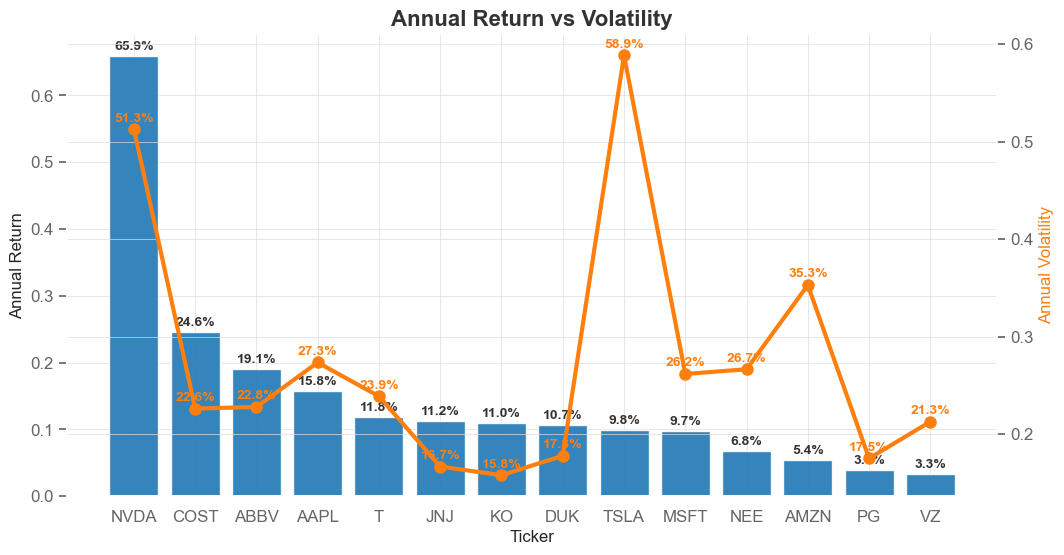

In [3]:
# --- Compute daily log returns ---
def compute_log_returns(data):
    if not isinstance(data.index, pd.DatetimeIndex):
        data.index = pd.to_datetime(data.index)
    return np.log(data / data.shift(1)).dropna()

returns = compute_log_returns(data)
print("✅ Log returns computed for portfolio tickers.")
print("\nPortfolio Returns Preview:")
display(returns.head())

# --- Step 5: Stock Metrics (Interactive Display) ---
def compute_stock_metrics_interactive(returns, trading_days):
    metrics = {}
    for ticker in returns.columns:
        r = returns[ticker]
        annual_return = np.exp(r.mean() * trading_days) - 1
        annual_vol = r.std() * np.sqrt(trading_days)
        metrics[ticker] = {'Annual Return': annual_return, 'Annual Volatility': annual_vol}

    df = pd.DataFrame(metrics).T
    df = df.sort_values('Annual Return', ascending=False)

    # Add trend arrows and format percentages
    df['Annual Return'] = df['Annual Return'].apply(lambda x: f"🔺 {x:.2%}" if x >= 0 else f"🔻 {x:.2%}")
    df['Annual Volatility'] = df['Annual Volatility'].apply(lambda x: f"{x:.2%}")

    print("\n📊 Stock Metrics:")
    display(df)

    return metrics

# --- Call interactive version ---
stock_metrics = compute_stock_metrics_interactive(returns, trading_days)

import matplotlib.pyplot as plt
import pandas as pd

# --- Stock Metrics Plot: Legend Fully Outside ---
def plot_stock_metrics_matplotlib_legend_safe(metrics):
    df = pd.DataFrame(metrics).T
    df = df.sort_values('Annual Return', ascending=False)

    tickers = df.index
    returns = df['Annual Return'].values
    volatility = df['Annual Volatility'].values

    # Colors for bars
    colors = ['#1f77b4' if r >= 0 else '#d62728' for r in returns]
    volatility_color = '#ff7f0e'

    fig, ax1 = plt.subplots(figsize=(12,6))

    # Bar plot
    bars = ax1.bar(tickers, returns, color=colors, alpha=0.9, label='Annual Return')
    ax1.set_ylabel('Annual Return', fontsize=12)
    ax1.set_xlabel('Ticker', fontsize=12)
    ax1.set_title('Annual Return vs Volatility', fontsize=16, fontweight='bold')

    # Annotate returns
    for bar, r in zip(bars, returns):
        ax1.text(bar.get_x() + bar.get_width()/2, r + 0.005, f'{r:.1%}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

    # Line plot for volatility
    ax2 = ax1.twinx()
    ax2.plot(tickers, volatility, color=volatility_color, marker='o',
             markersize=8, linewidth=3, label='Annual Volatility')
    ax2.set_ylabel('Annual Volatility', color=volatility_color, fontsize=12)

    # Annotate volatility points
    for x, v in zip(tickers, volatility):
        ax2.text(x, v + 0.005, f'{v:.1%}', color=volatility_color,
                 ha='center', va='bottom', fontsize=10, fontweight='bold')


    plt.show()

# --- Call the safe version ---
plot_stock_metrics_matplotlib_legend_safe(stock_metrics)


=== Portfolio Metrics ===
           Metric  Value
    Annual Return 15.38%
Annual Volatility 15.80%


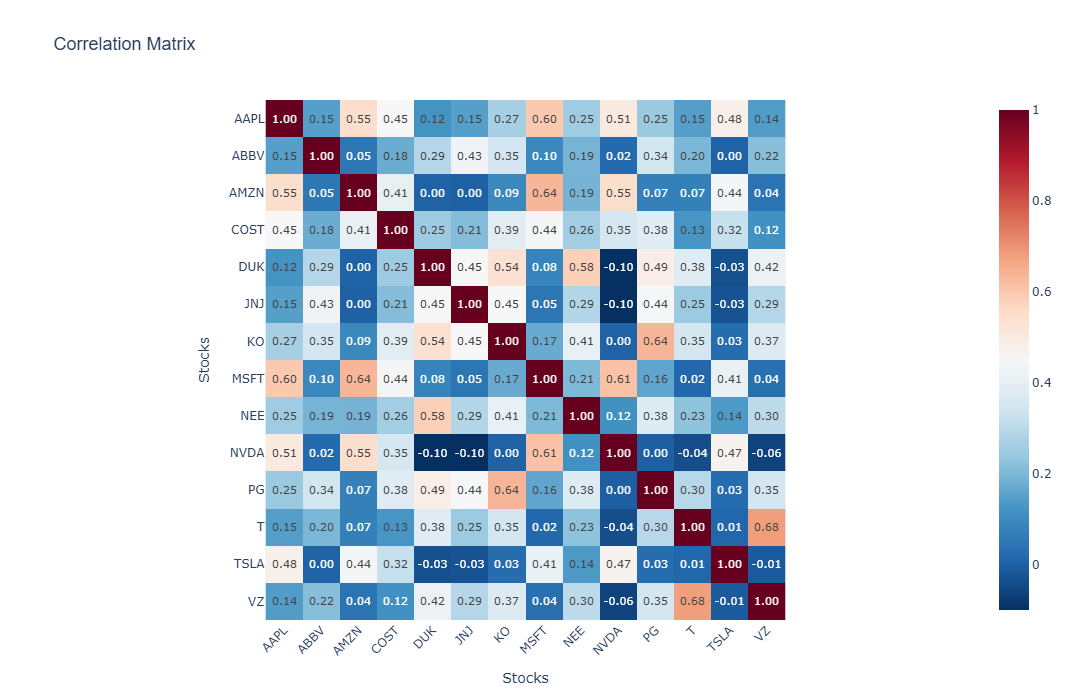

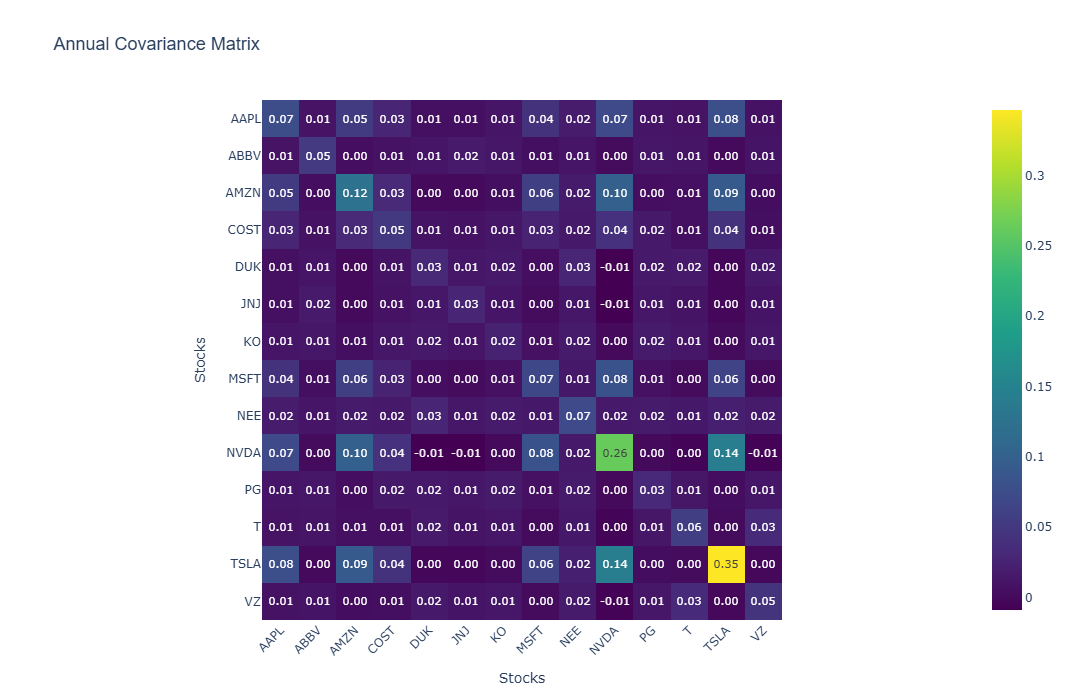

In [7]:
def compute_portfolio_metrics_fixed(returns, weights, trading_days):
    """
    Computes portfolio metrics and visualizes covariance/correlation matrices.
    Portfolio metrics are shown in a table; cov/corr are heatmaps.
    """
    # --- Portfolio daily returns ---
    port_returns = returns.dot(weights)
    
    # --- Annualized portfolio return & volatility ---
    annual_return = np.exp(port_returns.mean() * trading_days) - 1
    daily_cov = returns.cov()
    annual_cov = daily_cov * trading_days
    corr_matrix = returns.corr()
    annual_vol = (weights.T @ annual_cov @ weights)**0.5
    
    # --- Display portfolio metrics as table ---
    metrics_table = pd.DataFrame({
        "Metric": ["Annual Return", "Annual Volatility"],
        "Value": [f"{annual_return*100:.2f}%", f"{annual_vol*100:.2f}%"]
    })
    print("\n=== Portfolio Metrics ===")
    print(metrics_table.to_string(index=False))
    
    return annual_return, annual_vol, port_returns, daily_cov, annual_cov, corr_matrix

# --- Call the function ---
portfolio_return, portfolio_vol, port_daily_returns, daily_cov, annual_cov, corr_matrix = \
    compute_portfolio_metrics_fixed(returns, weights, trading_days)

# --- Function to plot heatmaps ---
def plot_matrix(matrix, title, color_scale='Viridis'):
    fig = px.imshow(
        matrix,
        text_auto=".2f",
        color_continuous_scale=color_scale,
        title=title,
        aspect="equal"  # makes cells square
    )
    fig.update_layout(
        title_font=dict(size=18, family="Arial, bold"),
        xaxis_title="Stocks",
        yaxis_title="Stocks",
        width=700,
        height=700,
        margin=dict(l=80, r=80, t=100, b=80),
        xaxis_tickangle=-45
    )
    fig.show()

# --- Plot heatmaps ---
plot_matrix(corr_matrix, "Correlation Matrix", color_scale='RdBu_r')
plot_matrix(annual_cov, "Annual Covariance Matrix", color_scale='Viridis')


=== Portfolio Metrics ===
           Metric  Value
    Annual Return 15.38%
Annual Volatility 15.80%

=== First 5 Days of Portfolio Growth ===
            Portfolio Value ($)  Percentage Growth (%)
Date                                                  
2021-04-01           100.751373               0.751373
2021-04-05           102.119274               2.119274
2021-04-06           102.223094               2.223094
2021-04-07           102.544671               2.544671
2021-04-08           103.032639               3.032639

=== Last 5 Days of Portfolio Growth ===
            Portfolio Value ($)  Percentage Growth (%)
Date                                                  
2026-03-24           205.102874             105.102874
2026-03-25           206.348480             106.348480
2026-03-26           204.722388             104.722388
2026-03-27           203.099033             103.099033
2026-03-30           203.809712             103.809712


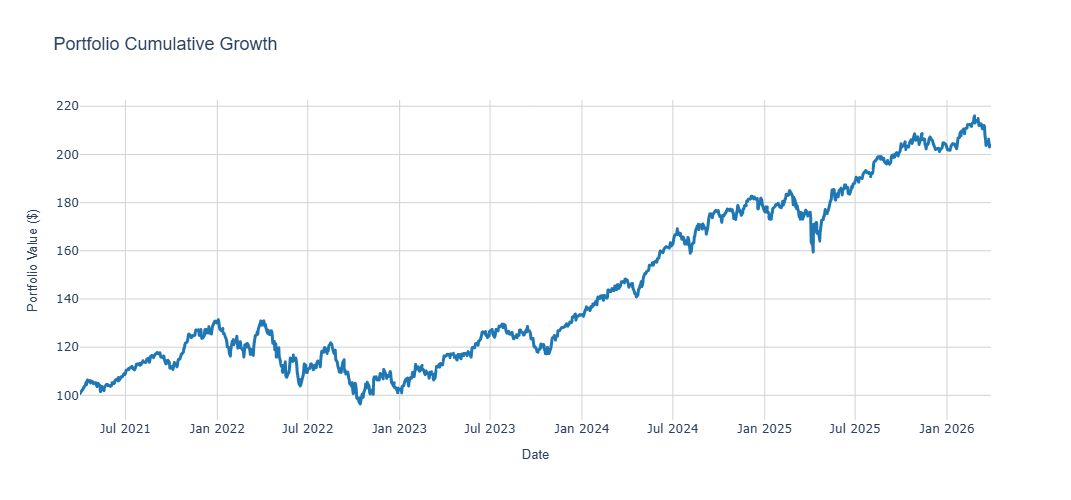

In [8]:
# --- Portfolio Metrics Table ---
def display_portfolio_metrics(annual_return, annual_vol):
    metrics_table = pd.DataFrame({
        "Metric": ["Annual Return", "Annual Volatility"],
        "Value": [f"{annual_return*100:.2f}%", f"{annual_vol*100:.2f}%"]
    })
    print("\n=== Portfolio Metrics ===")
    print(metrics_table.to_string(index=False))
    return metrics_table

# --- Plot cumulative portfolio growth with head & tail tables ---
def plot_cumulative_growth(port_returns, initial_value=100):
    # Ensure datetime index
    if not isinstance(port_returns.index, pd.DatetimeIndex):
        port_returns.index = pd.to_datetime(port_returns.index)

    # Compute cumulative growth
    cumulative_value = initial_value * np.exp(port_returns.cumsum())
    pct_growth = (cumulative_value / initial_value - 1) * 100

    # Combine into DataFrame
    growth_df = pd.DataFrame({
        "Portfolio Value ($)": cumulative_value,
        "Percentage Growth (%)": pct_growth
    }, index=port_returns.index)

    # Show head table
    head_table = growth_df.head(5)
    print("\n=== First 5 Days of Portfolio Growth ===")
    print(head_table.to_string())

    # Show tail table
    tail_table = growth_df.tail(5)
    print("\n=== Last 5 Days of Portfolio Growth ===")
    print(tail_table.to_string())

    # Plot line chart (smooth line)
    fig = px.line(
        growth_df,
        y="Portfolio Value ($)",
        title="Portfolio Cumulative Growth",
        labels={"Portfolio Value ($)": "Portfolio Value ($)", "index": "Date"}
    )
    fig.update_traces(line=dict(color="#1f77b4", width=3))  # smooth line
    fig.update_layout(
        title_font=dict(size=18, family="Arial, bold"),
        xaxis_title="Date",
        yaxis_title="Portfolio Value ($)",
        xaxis_title_font=dict(size=13, family="Arial, bold"),
        yaxis_title_font=dict(size=13, family="Arial, bold"),
        width=900,
        height=500,
        template="plotly_white",
        hovermode="x unified",
        xaxis=dict(showgrid=True, gridcolor="lightgrey"),
        yaxis=dict(showgrid=True, gridcolor="lightgrey")
    )
    fig.show()

    return growth_df, head_table, tail_table

# --- Example usage ---
display_portfolio_metrics(portfolio_return, portfolio_vol)
portfolio_growth_df, head_growth_table, tail_growth_table = plot_cumulative_growth(port_daily_returns)

In [22]:
# --- Step 10: Risk-Free Rate (Close Only, Fixed for FutureWarning) ---
def get_risk_free_rate(start, end, rf_ticker):
    # Download Close price for the risk-free asset
    rf_data = yf.download(rf_ticker, start=start, end=end, progress=False)['Close']
    if rf_data.empty:
        raise RuntimeError(f"No data found for risk-free rate ticker {rf_ticker}.")

    # Ensure numeric
    rf_series = rf_data.astype(float)
    
    # Compute scalar annual rate safely
    annual_rf = rf_series.mean()
    if isinstance(annual_rf, pd.Series):
        annual_rf = annual_rf.iloc[0]
    annual_rf = annual_rf / 100.0  # percent -> decimal

    # Compute daily rate using predefined trading_days
    daily_rf = (1 + annual_rf)**(1/trading_days) - 1

    # Interactive display
    print(f"\nRisk-Free Ticker Used: {rf_ticker}")
    print(f"Daily Risk-Free Rate: {daily_rf:.6f}")
    print(f"Annualized Risk-Free Rate: {annual_rf:.4%}")

    return daily_rf, annual_rf

# Corrected call
daily_rf, annual_rf = get_risk_free_rate(start_date, end_date, rf_ticker)

# --- Step 11: Benchmark ---
def download_benchmark(market_portfolio, start=None, end=None):

    benchmark_data = yf.download(market_portfolio, start=start, end=end, progress=False)['Close']
    
    if benchmark_data.empty:
        raise RuntimeError(f"No benchmark data found for {market_portfolio}")

    benchmark_data = benchmark_data.ffill().bfill()
    benchmark_returns = np.log(benchmark_data / benchmark_data.shift(1)).dropna()
    
    return benchmark_data, benchmark_returns

# --- Step 12: Benchmark Metrics ---
def compute_benchmark_metrics(daily_returns, trading_days):
    """
    Computes benchmark annual return and volatility from daily log returns.
    """
    # Ensure single series
    if isinstance(daily_returns, pd.DataFrame) and daily_returns.shape[1] > 1:
        raise ValueError("Benchmark returns must be a single column/Series")
    daily_returns = daily_returns.iloc[:,0] if isinstance(daily_returns, pd.DataFrame) else daily_returns

    # Annualized metrics
    annual_return = np.exp(daily_returns.mean() * trading_days) - 1
    annual_vol = daily_returns.std() * np.sqrt(trading_days)

    return {
        'annual_return': float(annual_return),
        'annual_vol': float(annual_vol)
    }

# --- Example usage ---
benchmark_prices, benchmark_daily_returns = download_benchmark(market_ticker, start_date, end_date)
benchmark_daily_returns = benchmark_daily_returns.to_frame() if isinstance(benchmark_daily_returns, pd.Series) else benchmark_daily_returns

benchmark_metrics = compute_benchmark_metrics(benchmark_daily_returns, trading_days)
print(f"\n=== Benchmark ({market_ticker}) Metrics ===")
print(f"Annual Return = {benchmark_metrics['annual_return']:.2%}")
print(f"Annual Volatility = {benchmark_metrics['annual_vol']:.2%}")




Risk-Free Ticker Used: ^IRX
Daily Risk-Free Rate: 0.000132
Annualized Risk-Free Rate: 3.3823%

=== Benchmark (^GSPC) Metrics ===
Annual Return = 9.86%
Annual Volatility = 16.85%


In [23]:
# --- Ensure benchmark returns is a Series ---
benchmark_returns = benchmark_daily_returns.iloc[:, 0] if isinstance(benchmark_daily_returns, pd.DataFrame) else benchmark_daily_returns

# --- Step 1: Regression for Beta and Alpha ---
import statsmodels.api as sm

X = sm.add_constant(benchmark_returns)  # adds intercept for alpha
model = sm.OLS(port_daily_returns, X).fit()

portfolio_alpha_daily = model.params['const']
portfolio_beta = model.params[benchmark_returns.name]

# --- Step 2: Annualize Alpha ---
trading_days = 252
portfolio_alpha_annual = np.exp(portfolio_alpha_daily * trading_days) - 1

# --- Step 3: CAPM Expected Return ---
annual_market_return = np.exp(benchmark_returns.mean() * trading_days) - 1
capm_portfolio_return = annual_rf + portfolio_beta * (annual_market_return - annual_rf)

# --- Step 4: Metrics Table ---
import pandas as pd
metrics_table = pd.DataFrame({
    "Metric": [
        "Portfolio Beta",
        "Portfolio Daily Alpha",
        "Portfolio Annualized Alpha",
        "Portfolio CAPM Expected Return"
    ],
    "Value": [
        f"{portfolio_beta:.4f}",
        f"{portfolio_alpha_daily*100:.4f}%",
        f"{portfolio_alpha_annual*100:.4f}%",
        f"{capm_portfolio_return*100:.4f}%"
    ]
})

print("\n=== Portfolio CAPM & Beta Metrics ===")
print(metrics_table)

# --- Step 5: Regression Summary ---
print("\n=== Regression Detailed Summary ===")
print(model.summary())


=== Portfolio CAPM & Beta Metrics ===
                           Metric    Value
0                  Portfolio Beta   0.8497
1           Portfolio Daily Alpha  0.0251%
2      Portfolio Annualized Alpha  6.5216%
3  Portfolio CAPM Expected Return  8.8869%

=== Regression Detailed Summary ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.822
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     5777.
Date:                Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                        11:46:09   Log-Likelihood:                 5084.1
No. Observations:                1254   AIC:                        -1.016e+04
Df Residuals:                    1252   BIC:                        -1.015e+04
Df Model:                           1                                        

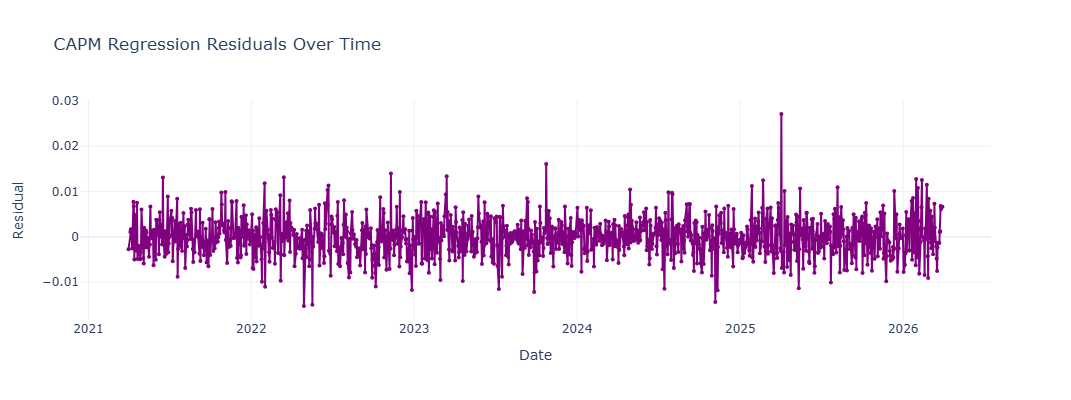

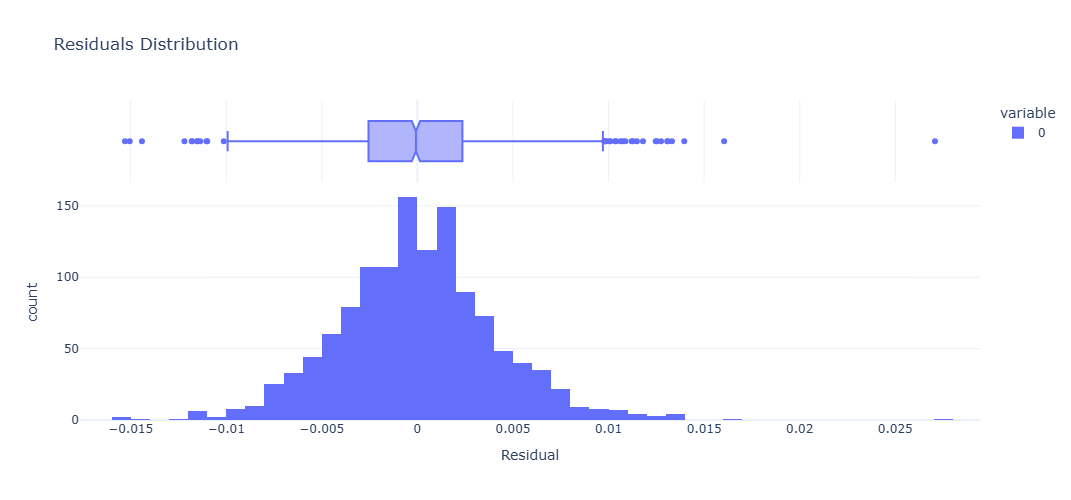

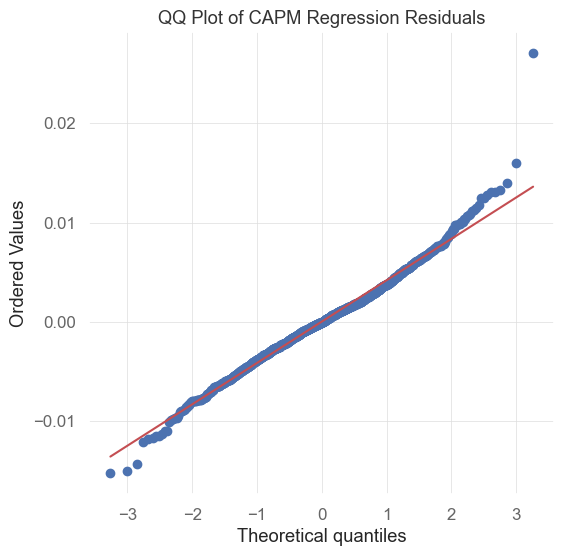

In [24]:
residuals = port_daily_returns - (portfolio_alpha_daily + portfolio_beta * benchmark_returns)

import plotly.graph_objects as go
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=residuals.index,
    y=residuals,
    mode='lines+markers',
    name='Residuals',
    marker=dict(color='purple', size=4)
))
fig.update_layout(
    title='CAPM Regression Residuals Over Time',
    xaxis_title='Date',
    yaxis_title='Residual',
    template='plotly_white',
    width=900, height=400
)
fig.show()

import plotly.express as px
fig = px.histogram(
    residuals, nbins=50, marginal='box',
    title='Residuals Distribution',
    labels={'value': 'Residual'}
)
fig.update_layout(template='plotly_white', width=800, height=500)
fig.show()

import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot of CAPM Regression Residuals")
plt.show()

In [26]:
# --- Ensure CAPM regression has been run ---
# portfolio_alpha_daily and portfolio_beta come from regression
portfolio_alpha = np.exp(portfolio_alpha_daily * trading_days) - 1  # annualized

benchmark_series = benchmark_daily_returns.iloc[:,0] if isinstance(benchmark_daily_returns, pd.DataFrame) else benchmark_daily_returns
benchmark_annual_vol = benchmark_series.std() * np.sqrt(trading_days)
benchmark_annual_return = np.exp(benchmark_series.mean() * trading_days) - 1

# --- Risk-Adjusted Ratios ---
sharpe_ratio = qs.stats.sharpe(port_daily_returns, rf=daily_rf)
sortino_ratio = qs.stats.sortino(port_daily_returns, rf=daily_rf)
treynor_ratio = (portfolio_return - daily_rf * trading_days) / portfolio_beta
m2 = daily_rf * trading_days + sharpe_ratio * benchmark_annual_vol
max_drawdown = qs.stats.max_drawdown(port_daily_returns)
calmar_ratio = portfolio_return / abs(max_drawdown)
excess_returns = port_daily_returns - benchmark_series
tracking_error = excess_returns.std() * np.sqrt(trading_days)
information_ratio = (portfolio_return - benchmark_annual_return) / tracking_error
capm_expected_return = daily_rf + portfolio_beta * (benchmark_annual_return - daily_rf)

# --- Metrics Tables ---
performance_table = pd.DataFrame({
    "Metric": ["Annualized Return", "Annualized Volatility", "Max Drawdown"],
    "Value": [f"{portfolio_return*100:.2f}%", f"{portfolio_vol*100:.2f}%", f"{max_drawdown*100:.2f}%"]
})

capm_table = pd.DataFrame({
    "Metric": ["Alpha", "Beta", "CAPM Expected Return", "M² (Modigliani Risk-Adjusted)"],
    "Value": [f"{portfolio_alpha*100:.2f}%", f"{portfolio_beta:.4f}", f"{capm_expected_return*100:.2f}%", f"{m2*100:.2f}%"]
})

ratios_table = pd.DataFrame({
    "Metric": ["Sharpe Ratio", "Sortino Ratio", "Treynor Ratio", "Calmar Ratio", "Information Ratio"],
    "Value": [f"{sharpe_ratio:.4f}", f"{sortino_ratio:.4f}", f"{treynor_ratio:.4f}", f"{calmar_ratio:.4f}", f"{information_ratio:.4f}"]
})

print("\n=== Portfolio Performance Metrics ===")
display(performance_table)

print("\n=== Portfolio CAPM Metrics ===")
display(capm_table)

print("\n=== Portfolio Risk-Adjusted Ratios ===")
display(ratios_table)


=== Portfolio Performance Metrics ===


,Metric,Value
0,Annualized Return,15.38%
1,Annualized Volatility,15.80%
2,Max Drawdown,-28.32%



=== Portfolio CAPM Metrics ===


,Metric,Value
0,Alpha,6.52%
1,Beta,0.8497
2,CAPM Expected Return,8.38%
3,M² (Modigliani Risk-Adjusted),18.58%



=== Portfolio Risk-Adjusted Ratios ===


,Metric,Value
0,Sharpe Ratio,0.9050
1,Sortino Ratio,1.2970
2,Treynor Ratio,0.1419
3,Calmar Ratio,0.5432
4,Information Ratio,0.7744


In [28]:
import numpy as np
import scipy.stats as stats
import quantstats as qs
import pandas as pd

# --- Max Drawdown ---
max_drawdown = qs.stats.max_drawdown(port_daily_returns)

# --- Value at Risk (5%) ---
var_5_daily = np.percentile(port_daily_returns, 5)
var_5_annual = var_5_daily * np.sqrt(trading_days)

# --- Conditional Value at Risk (5%) ---
cvar_5_daily = port_daily_returns[port_daily_returns <= var_5_daily].mean()
cvar_5_annual = cvar_5_daily * np.sqrt(trading_days)

# --- Downside Deviation (manual) ---
MAR = 0  # minimum acceptable return (can also use daily_rf)
negative_returns = np.minimum(0, port_daily_returns - MAR)
downside_deviation = np.sqrt(np.mean(negative_returns**2))

# --- Skewness & Kurtosis ---
skewness = stats.skew(port_daily_returns)
kurtosis = stats.kurtosis(port_daily_returns)

# --- Risk Metrics Table ---
advanced_table = pd.DataFrame({
    "Metric": [
        "Max Drawdown",
        "VaR 5% (daily)",
        "VaR 5% (annualized)",
        "CVaR 5% (daily)",
        "CVaR 5% (annualized)",
        "Downside Deviation",
        "Skewness",
        "Kurtosis"
    ],
    "Value": [
        f"{max_drawdown*100:.2f}%",
        f"{var_5_daily*100:.2f}%",
        f"{var_5_annual*100:.2f}%",
        f"{cvar_5_daily*100:.2f}%",
        f"{cvar_5_annual*100:.2f}%",
        f"{downside_deviation*100:.2f}%",
        f"{skewness:.4f}",
        f"{kurtosis:.4f}"
    ]
})

print("\n=== Portfolio Advanced Risk Metrics ===")
display(advanced_table)


=== Portfolio Advanced Risk Metrics ===


,Metric,Value
0,Max Drawdown,-28.32%
1,VaR 5% (daily),-1.53%
2,VaR 5% (annualized),-24.28%
3,CVaR 5% (daily),-2.30%
4,CVaR 5% (annualized),-36.49%
5,Downside Deviation,0.69%
6,Skewness,-0.1638
7,Kurtosis,5.2877


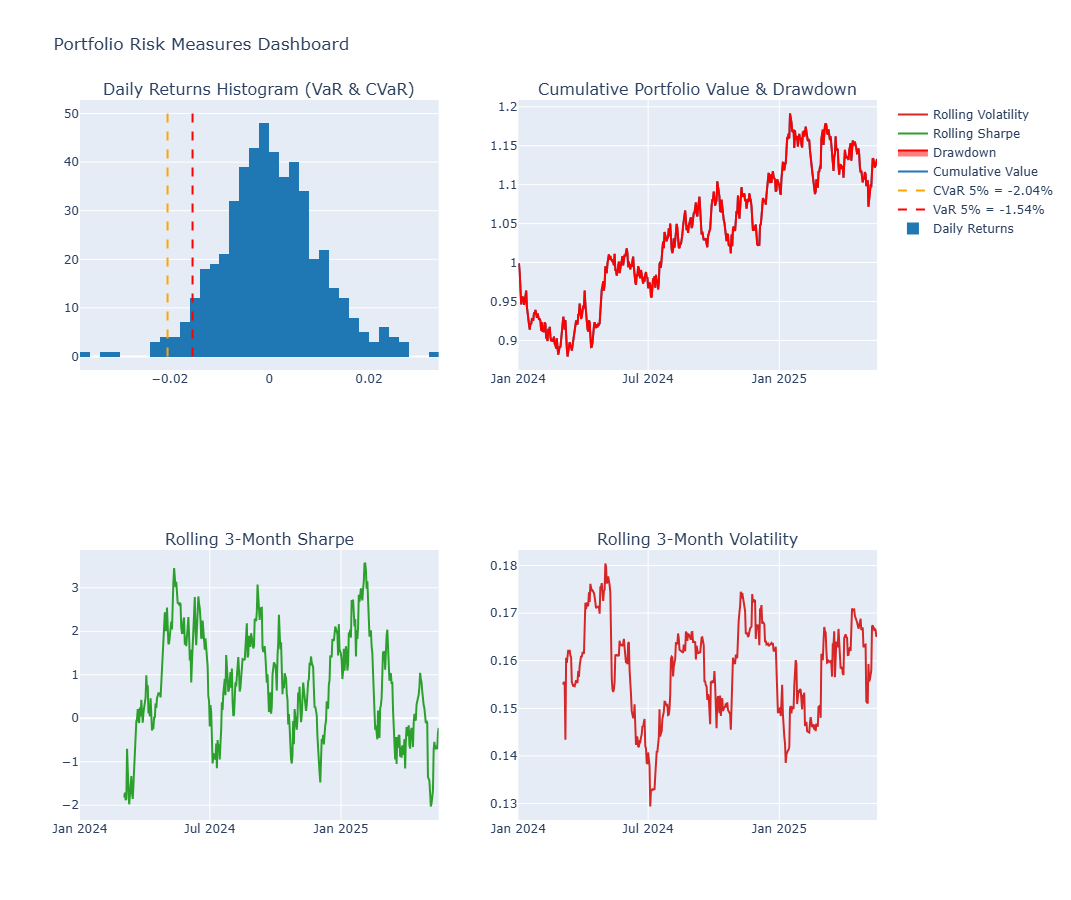

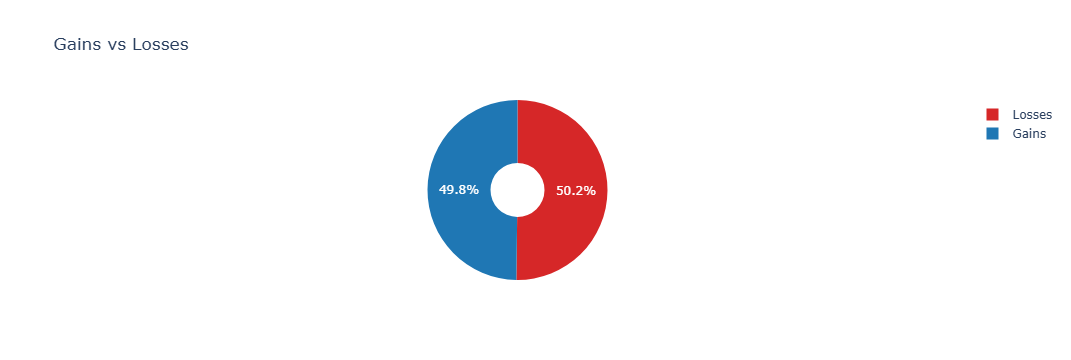

In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import quantstats as qs

# --- Example: assume you have your portfolio daily returns ---
# Replace this with your actual port_daily_returns Series
port_daily_returns = pd.Series(np.random.normal(0.0005, 0.01, 252*2), 
                               index=pd.date_range("2024-01-01", periods=252*2))

trading_days = 252

# --- Compute VaR & CVaR ---
var_5_daily = np.percentile(port_daily_returns, 5)
cvar_5_daily = port_daily_returns[port_daily_returns <= var_5_daily].mean()

# --- Compute cumulative portfolio value & drawdown ---
cumulative_value = (1 + port_daily_returns).cumprod()
rolling_max = cumulative_value.cummax()
drawdown = (cumulative_value - rolling_max) / rolling_max

# --- Rolling metrics ---
rolling_window = 63
rolling_sharpe = port_daily_returns.rolling(window=rolling_window).apply(
    lambda x: qs.stats.sharpe(x, annualize=True), raw=False)
rolling_vol = port_daily_returns.rolling(window=rolling_window).apply(
    lambda x: qs.stats.volatility(x, annualize=True), raw=False)

# --- Create subplots ---
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Daily Returns Histogram (VaR & CVaR)",
        "Cumulative Portfolio Value & Drawdown",
        "Rolling 3-Month Sharpe",
        "Rolling 3-Month Volatility"
    )
)

# Histogram + VaR/CVaR lines
fig.add_trace(go.Histogram(x=port_daily_returns, nbinsx=50, name="Daily Returns", marker_color="#1f77b4"), row=1, col=1)
fig.add_trace(go.Scatter(x=[var_5_daily, var_5_daily], y=[0, 50], mode="lines", 
                         name=f"VaR 5% = {var_5_daily*100:.2f}%", line=dict(color="red", dash="dash")), row=1, col=1)
fig.add_trace(go.Scatter(x=[cvar_5_daily, cvar_5_daily], y=[0, 50], mode="lines", 
                         name=f"CVaR 5% = {cvar_5_daily*100:.2f}%", line=dict(color="orange", dash="dash")), row=1, col=1)

# Cumulative value & drawdown
fig.add_trace(go.Scatter(x=cumulative_value.index, y=cumulative_value, mode='lines', 
                         name="Cumulative Value", line=dict(color="#1f77b4")), row=1, col=2)
fig.add_trace(go.Scatter(x=drawdown.index, y=rolling_max + drawdown*rolling_max, mode='lines', 
                         fill='tonexty', name="Drawdown", line=dict(color="red"), opacity=0.3), row=1, col=2)

# Rolling Sharpe
fig.add_trace(go.Scatter(x=rolling_sharpe.index, y=rolling_sharpe, mode='lines', 
                         name="Rolling Sharpe", line=dict(color="#2ca02c")), row=2, col=1)

# Rolling Volatility
fig.add_trace(go.Scatter(x=rolling_vol.index, y=rolling_vol, mode='lines', 
                         name="Rolling Volatility", line=dict(color="#d62728")), row=2, col=2)

fig.update_layout(height=900, width=1000, title_text="Portfolio Risk Measures Dashboard")
fig.show()

# --- Pie chart ---
gains = (port_daily_returns >= 0).sum()
losses = (port_daily_returns < 0).sum()
fig_pie = go.Figure(go.Pie(labels=["Gains", "Losses"], values=[gains, losses], hole=0.3, 
                           marker_colors=["#1f77b4","#d62728"]))
fig_pie.update_layout(title_text="Gains vs Losses")
fig_pie.show()

✅ Excel report saved to desktop: C:\Users\DELL-H\Desktop\Portfolio_Report.xlsx
